In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import pickle
import deepRD.tools.trajectoryTools as trajectoryTools
import csv
import math
from deepRD.noiseSampler import noiseSampler
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import gaussian_kde, wasserstein_distance_nd

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
# System type: 'bistable', 'dimer'
systemType = 'dimer'

# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
conditionedOn = 'pidqiri'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim for benchmark
# for dimer, alternating between particle 1 and particle 2.

#for generated trajs, 
# datapoint = [time (1), qi (3), vi (3), ri(3)] - 10 dim

# Datasets directory
localDirectoryBase = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/"

# loading multiple simulation folders for comparisons, and corresponding labels

datasetFolders = ["benchmarkReducedGen_piri/"]#, "benchmarkReducedGen_pidqiri"]
datasetLabels = ["piri"]#, "pidqiri"]
nModels = len(datasetFolders)

nTrajs = 100 # no. of trajectories to load per data folder

nTimestepsBench = 10000 # length of benchmark trajectory
nTimesteps = 200000 # length of coarse-grained trajectory
datapointDim = 10 # dimensionality of datapoints.
numFilesBench = 2500
numFiles = 100 # total no. of files in data folder

#mean_d = torch.tensor([ 4.9998e+02, -1.6760e-02,  3.3266e-03, -1.7140e-03, -1.2232e-05, 
#                        -7.2127e-05,  6.9702e-05, 2.0080e-07,  6.3679e-06, -2.9733e-06])
#std_d = torch.tensor([1.4434e+02, 1.3641e+00, 7.3784e-01, 7.3927e-01, 1.4253e-01, 1.4252e-01, 
#                    1.4256e-01, 1.6200e-02, 1.6212e-02, 1.6207e-02])

# Initialising tensor to store trajectories
dataset = torch.empty((nModels, nTrajs, 2*nTimesteps, datapointDim))
    
# Loading reduced models data

truncate = False # if True, will select random fragment of trajectory

for i, datasetFolder in enumerate(datasetFolders):
    
    filePath = localDirectoryBase + datasetFolder + "simMoriZwanzigReduced_"    
    
    fileIDS = np.sort(np.random.choice(numFiles, nTrajs, replace=False))
    if i==1:
        print(fileIDS)
    
    for j, fnum in enumerate(fileIDS):
        try:
            ds = torch.Tensor(trajectoryTools.loadTrajectory(filePath, fnum))
        except FileNotFoundError:
            print(f'File {fnum} not available', end='\r')
            continue
            
        dataset[i, j] = ds

#dataset_norm = (dataset[0] - mean_d)/std_d
dataset.shape # nModels, nTrajs, nTimesteps, datapointDims

torch.Size([1, 100, 400000, 10])

In [5]:
# Loading Benchmark data

benchDataset = torch.empty((nTrajs, 2*nTimestepsBench, datapointDim))

fileIDS = np.sort(np.random.choice(numFilesBench, nTrajs, replace=False))

benchFileDirectory = localDirectoryBase + "benchmark/simMoriZwanzig_"

for j, fnum in enumerate(fileIDS):
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(benchFileDirectory, fnum))
    except FileNotFoundError:
        print(f'File {fnum} not available')
        continue
    print(f'File no. {fnum} loaded', end='\r')
    # cutting out meaningless variable
    if ds.shape[1]==11:
        ds = torch.cat((ds[:, :7], ds[:, -3:]), dim=1)
    
    benchDataset[j] = ds
    
benchDataset.shape

torch.Size([100, 20000, 10])

In [6]:
b_timesteps = benchDataset[:, ::2, 0]
b_qT = torch.cat((benchDataset[:, ::2, 1:4], benchDataset[:, 1::2, 1:4]), dim=-1)
b_rAuxT = torch.cat((benchDataset[:, ::2, -3:], benchDataset[:, 1::2, -3:]), dim=-1)
b_rNxtT = torch.roll(b_rAuxT, -1, 1)
b_vT = torch.cat((benchDataset[:, ::2, 4:7], benchDataset[:, 1::2, 4:7]), dim=-1)

# 0:3 - particle 1, 3:6 - particle 2
timesteps = dataset[:, :, ::2, 0]
qT = torch.cat((dataset[:, :, ::2, 1:4], dataset[:, :, 1::2, 1:4]), dim=-1)
rAuxT = torch.cat((dataset[:, :, ::2, -3:], dataset[:, :, 1::2, -3:]), dim=-1)
rNxtT = torch.roll(rAuxT, -1, 1)
vT = torch.cat((dataset[:, :, ::2, 4:7], dataset[:, :, 1::2, 4:7]), dim=-1)

b_timesteps.shape, b_qT.shape, b_rAuxT.shape, b_rNxtT.shape, b_vT.shape, timesteps.shape, qT.shape, rAuxT.shape, rNxtT.shape, vT.shape

(torch.Size([100, 10000]),
 torch.Size([100, 10000, 6]),
 torch.Size([100, 10000, 6]),
 torch.Size([100, 10000, 6]),
 torch.Size([100, 10000, 6]),
 torch.Size([1, 100, 200000]),
 torch.Size([1, 100, 200000, 6]),
 torch.Size([1, 100, 200000, 6]),
 torch.Size([1, 100, 200000, 6]),
 torch.Size([1, 100, 200000, 6]))

In [7]:
mID = 0 # determine which of the reduced models should be analysed.
# Additional models IDs, or set None to omit
mID_2 = 1
mID_3 = 2

In [8]:
print('Velocity')

print(f'Mean Bench: \t', torch.mean(b_vT, dim=(0,1)))
#print('Mean Reduced 1:\t', torch.mean(vT[mID], dim=(0,1)))

print('\nStd Bench: \t', torch.std(b_vT, dim=(0,1)))
#print('Std Reduced 1:\t', torch.std(vT[mID], dim=(0,1)))
    
print('\n Auxiliary Var')
print('Mean Bench: \t', torch.mean(b_rAuxT, dim=(0,1)))
#print('Mean Reduced:\t', torch.mean(rAuxT[mID], dim=(0,1)))

print('\nStd Bench: \t', torch.std(b_rAuxT, dim=(0,1)))
#print('Std Reduced 1:\t', torch.std(rAuxT[mID], dim=(0,1)))

Velocity
Mean Bench: 	 tensor([-0.0010,  0.0015,  0.0007, -0.0009,  0.0017,  0.0007])

Std Bench: 	 tensor([0.1422, 0.1424, 0.1421, 0.1425, 0.1423, 0.1419])

 Auxiliary Var
Mean Bench: 	 tensor([ 1.6100e-05,  8.7235e-06, -1.9394e-06, -1.2150e-05, -2.3168e-06,
         5.4224e-06])

Std Bench: 	 tensor([0.0161, 0.0161, 0.0161, 0.0161, 0.0161, 0.0161])


In [9]:
def compute_delta_x_loop(q1, q2, boxsize=5.0, boundary_type="periodic"):
    """
    Compute Δx = ||relativePosition(q1, q2)|| using the original loop-based
    trajectoryTools.relativePosition function.
    
    Returns
    -------
    delta_x : np.ndarray of shape [n_traj, T]
    """
    
    # convert to numpy arrays
    q1_np = q1.cpu().numpy()
    q2_np = q2.cpu().numpy()

    n_traj, T, _ = q1_np.shape
    delta_x = np.zeros((n_traj, T), dtype=np.float64)

    for i in range(n_traj):
        for j in range(T):
            relPos = trajectoryTools.relativePosition(
                q1_np[i, j],
                q2_np[i, j],
                boundary_type,
                boxsize
            )
            delta_x[i, j] = np.linalg.norm(relPos)

    return delta_x


def minimal_image_rel(q1, q2, boxsize=None, boundary_type='periodic'):
    """
    q1, q2: [..., 3] torch tensors
    returns q2 - q1 with minimal-image convention matching trajectoryTools.relativePosition
    """
    rel = q2 - q1  # [..., 3]

    if boundary_type == "periodic" and boxsize is not None:
        # box: tensor of shape [3]
        if isinstance(boxsize, (list, tuple, np.ndarray)):
            box = torch.tensor(boxsize, dtype=rel.dtype, device=rel.device)
        else:  # scalar -> same in all dims
            box = torch.full((3,), float(boxsize), dtype=rel.dtype, device=rel.device)

        # broadcast box over leading dims, minimal image per component
        rel = rel - box * torch.round(rel / box)

    return rel

def compute_axisRelVel(q1, q2, v1, v2, boxsize, boundary_type="periodic"):
    """
    Computes axis-relative velocity for a dimer in a fully vectorised way.

    Inputs:
      q1, q2: positions  [..., 3]
      v1, v2: velocities [..., 3]
      boxsize: scalar or 3-vector
      boundary_type: "periodic" or "none"

    Returns:
      axisRelVel: tensor [..., 1]
    """

    # Minimal-image relative position
    rel_pos = minimal_image_rel(q1, q2, boxsize, boundary_type)   # [..., 3]

    # Relative velocity
    rel_vel = v2 - v1                                             # [..., 3]

    # Unit vector along dimer axis
    norm_rel = torch.norm(rel_pos, dim=-1, keepdim=True)          # [..., 1]
    unit_rel = rel_pos / (norm_rel + 1e-12)                       # avoid div-by-zero

    # Projection of relative velocity onto dimer axis
    axis_rel_vel = torch.sum(rel_vel * unit_rel, dim=-1, keepdim=False)  # [..., 1]

    return axis_rel_vel

def plot_dimer_distributions(q1, q2, v1, v2, boxsize=5.0, compare=True):
    """
    Plot Δx distribution (vectorised vs loop-based if compare=True)
    and axis-relative-velocity distribution on the right.

    Args:
        q1, q2 : torch tensors [n_traj, T, 3]
        v1, v2 : torch tensors [n_traj, T, 3]
        trajectoryTools : module providing relativePosition (needed only if compare=True)
        boxsize : float for PBC
        compare : bool
            If True → plot loop vs vectorised Δx comparison
            If False → compute & plot only vectorised Δx
    """

    # --------------------------------------
    # Δx vectorised
    # --------------------------------------
    rel = minimal_image_rel(q1, q2, boundary_type='periodic', boxsize=boxsize)
    delta_x2 = torch.norm(rel, dim=-1)                       # [n_traj, T]
    dx2 = delta_x2.reshape(-1).cpu().numpy()

    kde2 = gaussian_kde(dx2)
    xs_dx = np.linspace(dx2.min(), dx2.max(), 400)

    # --------------------------------------
    # Δx loop-based (only if compare=True)
    # --------------------------------------
    if compare:
        if trajectoryTools is None:
            raise ValueError("trajectoryTools must be provided when compare=True")

        delta_x1 = compute_delta_x_loop(q1, q2, boxsize=boxsize)
        dx1 = delta_x1.reshape(-1)
        kde1 = gaussian_kde(dx1)

        xmin = min(dx1.min(), dx2.min())
        xmax = max(dx1.max(), dx2.max())
        xs_dx = np.linspace(xmin, xmax, 400)

    # --------------------------------------
    # axis-relative velocity
    # --------------------------------------
    axisRelVel = compute_axisRelVel(q1, q2, v1, v2, boxsize=boxsize)
    arv = axisRelVel.reshape(-1).cpu().numpy()

    kde_arv = gaussian_kde(arv)
    xs_arv = np.linspace(arv.min(), arv.max(), 400)

    # --------------------------------------
    # plotting
    # --------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- LEFT PANEL ---
    if compare:
        axes[0].plot(xs_dx, kde1(xs_dx), lw=2, label="Δx (loop-based)")
        axes[0].plot(xs_dx, kde2(xs_dx), lw=2, linestyle="--", label="Δx (vectorised)")
        axes[0].set_title("Δx KDE Comparison")
    else:
        axes[0].plot(xs_dx, kde2(xs_dx), lw=2, color="steelblue", label="Δx (vectorised)")
        axes[0].set_title("Δx (vectorised only)")

    axes[0].set_xlabel("Δx")
    axes[0].set_ylabel("Density")
    axes[0].set_xlim([0, 2])
    axes[0].grid(alpha=0.2)
    axes[0].legend()

    # --- RIGHT PANEL ---
    axes[1].plot(xs_arv, kde_arv(xs_arv), lw=2, color='darkred')
    axes[1].set_title("Distribution of axis-relative velocity")
    axes[1].set_xlabel("axisRelVel")
    axes[1].set_ylabel("Density")
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
    
    return delta_x2, axisRelVel

In [10]:
# split particles
q1, q2 = b_qT[..., :3], b_qT[..., 3:]
v1, v2 = b_vT[..., :3], b_vT[..., 3:]

print(q1.shape, q2.shape, v1.shape, v2.shape)

torch.Size([100, 10000, 3]) torch.Size([100, 10000, 3]) torch.Size([100, 10000, 3]) torch.Size([100, 10000, 3])


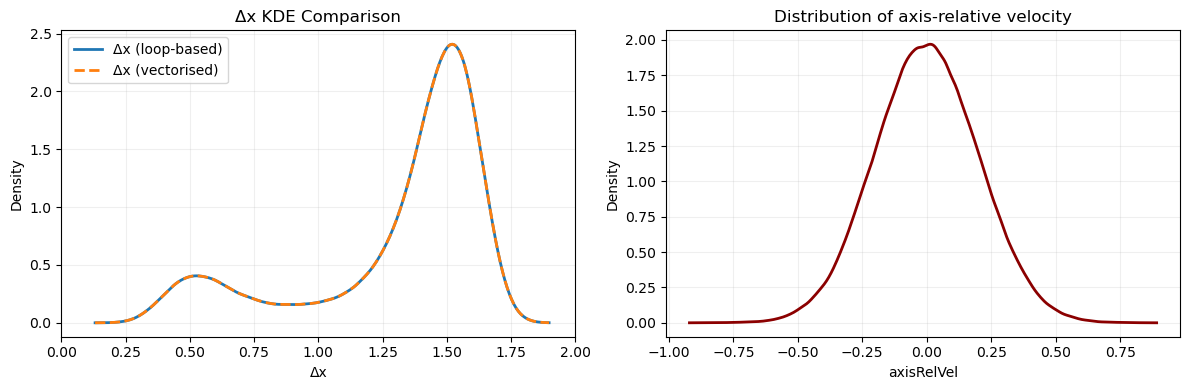

In [12]:
b_delta_x, b_delta_vx = plot_dimer_distributions(q1,q2,v1,v2,compare=True)

In [13]:
b_delta_x.shape, b_delta_vx.shape

(torch.Size([100, 10000]), torch.Size([100, 10000]))

In [12]:
def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    corr = np.fft.ifft(a_fft * np.conj(b_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr

In [13]:
lagtimesteps = 2000
mTrajs = 20

# ACF by FFT for 1-D traj, then summing up over vector dimensions and all trajs 
ACF_FFT = np.zeros((1, 2, lagtimesteps))
    
for trajInd in np.random.choice(nTrajs, mTrajs):
    
    #print('Benchmark')
    # position
    ACF_FFT[0, 0] += correlation_fft(b_delta_x[trajInd, :], b_delta_x[trajInd, :], lagtimesteps)
    # velocity
    ACF_FFT[0, 1] += correlation_fft(b_delta_vx[trajInd, :], b_delta_vx[trajInd, :], lagtimesteps)
    
ACF_FFT[0, 0] /= ACF_FFT[0, 0, 0]
ACF_FFT[0, 1] /= ACF_FFT[0, 1, 0]

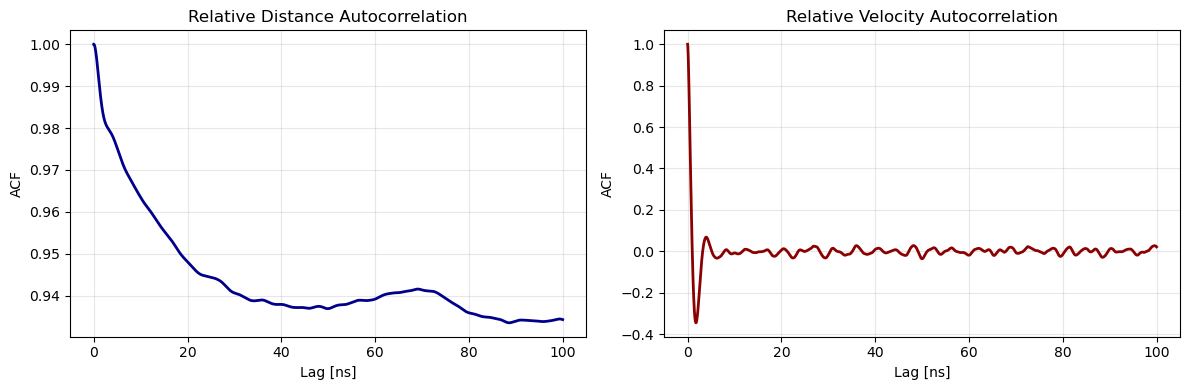

In [14]:
# lag axis
lags = np.arange(lagtimesteps)*0.05

# ACF arrays:
# ACF_FFT[0, 0] → Δx ACF
# ACF_FFT[0, 1] → Δv ACF
acf_dx = ACF_FFT[0, 0]
acf_dv = ACF_FFT[0, 1]

# ----- PLOTS -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: relative distance ACF ---
axes[0].plot(lags, acf_dx, lw=2, color="darkblue")
axes[0].set_title("Relative Distance Autocorrelation")
axes[0].set_xlabel("Lag [ns]")
axes[0].set_ylabel("ACF")
axes[0].grid(alpha=0.3)

# --- Right: relative velocity ACF ---
axes[1].plot(lags, acf_dv, lw=2, color="darkred")
axes[1].set_title("Relative Velocity Autocorrelation")
axes[1].set_xlabel("Lag [ns]")
axes[1].set_ylabel("ACF")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
#Calculating the Mean Squared Displacement of the particle.
b_rT = torch.norm(b_qT, dim=-1)
b_diffsq = torch.diff(b_rT, dim=-1)**2
b_MSD = torch.mean(b_diffsq)

rT = torch.norm(qT, dim=-1)
diffsq = torch.diff(rT, dim=-1)**2
MSD = torch.mean(diffsq, dim=(1,2))

print('Mean Square Displacement:')
print('Benchmark:', float(b_MSD))

for i in range(MSD.shape[0]):
    print(f'Model {i+1}:', float(MSD[i]))

Mean Square Displacement:
Benchmark: 5.077170499134809e-05
Model 1: 0.0


(2, 10)


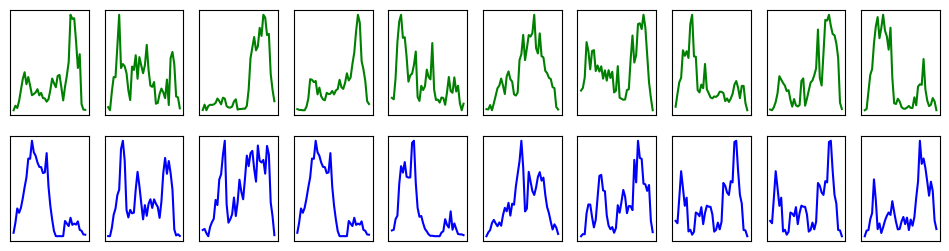

In [34]:
# Truncating
truncate = True

if truncate==True:
            
    sind = np.random.randint(4999, 190000) # starting ind for full-time trajectories
    eind = sind + nTimestepsBench

else:
    sind = 0
    eind = 200000

fig, axes = plt.subplots(2, 10, figsize=(12,3))
print(axes.shape)

trajInds = np.sort(np.random.choice(nTrajs, 10, replace=False))

for i, ind in enumerate(trajInds):
    
    # Benchmark
    pos, binEdges = np.histogram(b_qT[ind, :, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    axes[0, i].plot(binsPos, pos, c='g')
    
    # Reduced model
    pos, binEdges = np.histogram(qT[0, ind, sind:eind, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    axes[1, i].plot(binsPos, pos, c='b')
    
    axes[0, i].axes.get_xaxis().set_ticks([])
    axes[0, i].axes.get_yaxis().set_ticks([])
    axes[1, i].axes.get_xaxis().set_ticks([])
    axes[1, i].axes.get_yaxis().set_ticks([])

benchmark


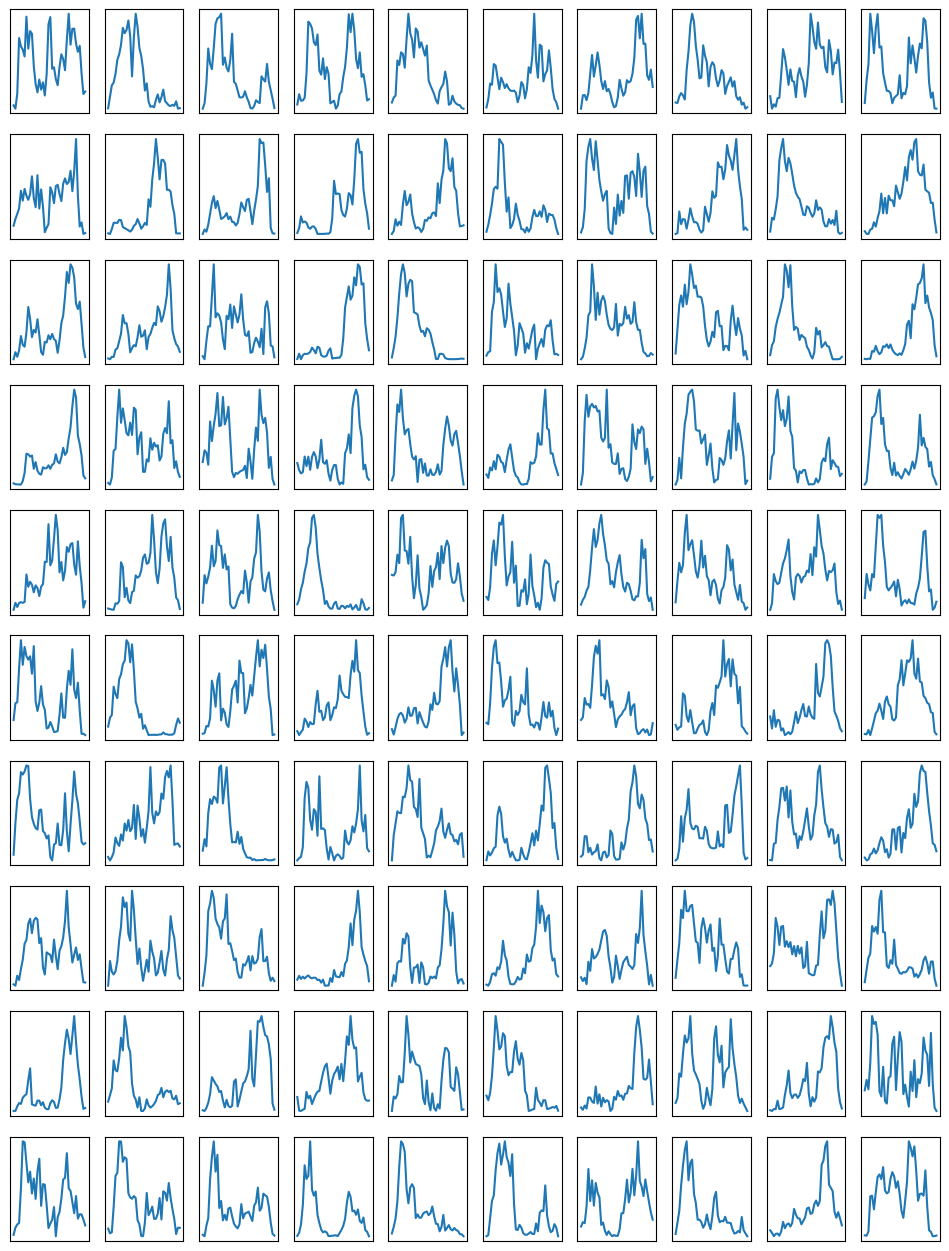

In [35]:
# BENCHMARK

fig = plt.figure(figsize=(12,16))

for i in range(nTrajs):
    
    pos, binEdges = np.histogram(b_qT[i, :, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    ax = fig.add_subplot(10, 10, i+1)
    ax.plot(binsPos, pos)
    ax.axes.get_xaxis().set_ticks([])
    ax.axes.get_yaxis().set_ticks([])

print("benchmark")
#fig.show()

reduced model


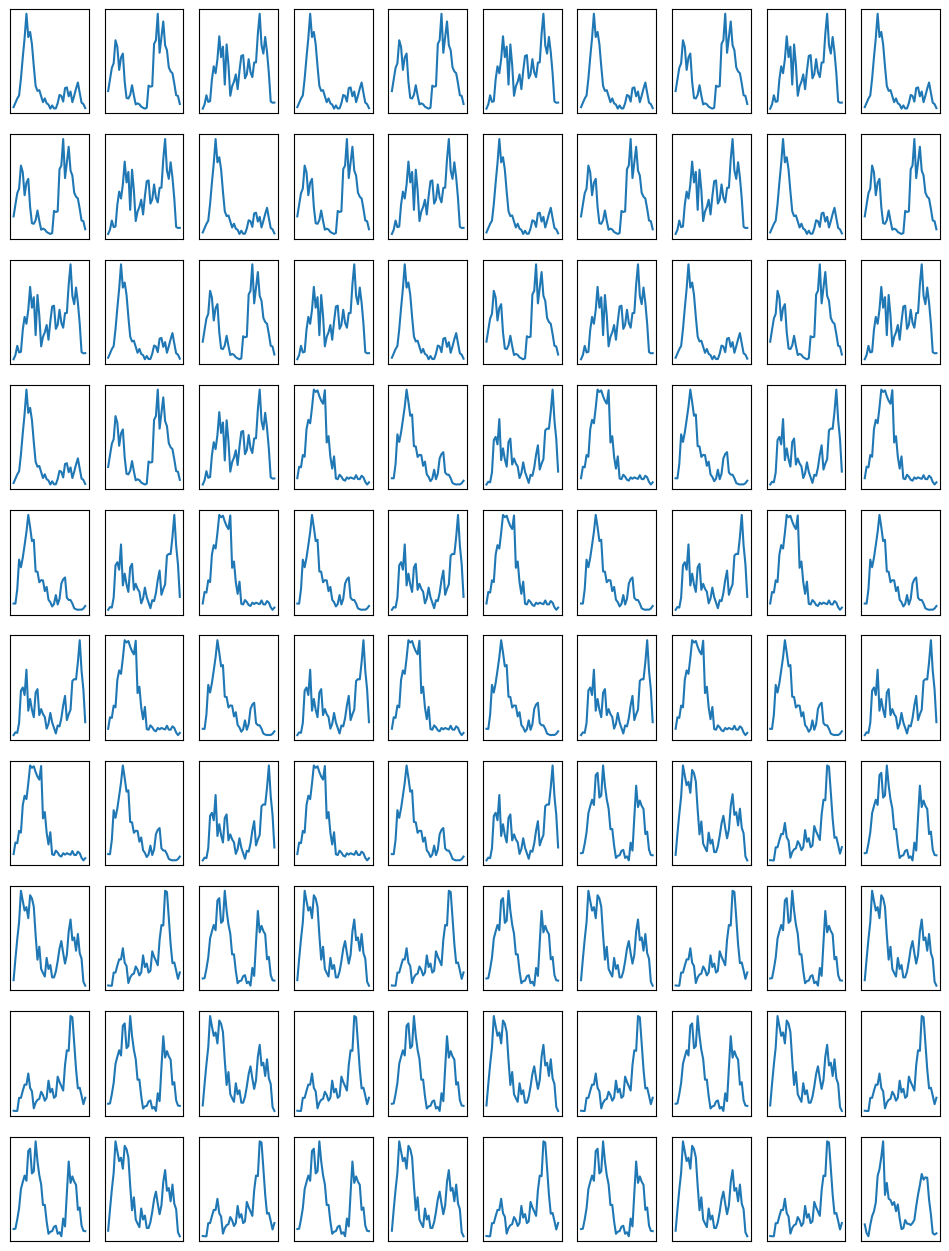

In [36]:
# REDUCED MODEL

fig = plt.figure(figsize=(12,16))

for i in range(nTrajs):
    
    pos, binEdges = np.histogram(qT[1, i, sind:eind, 0], bins=numbins, density=True);
    binsPos = 0.5 * (binEdges[1:] + binEdges[:-1])
    ax = fig.add_subplot(10, 10, i+1)
    ax.plot(binsPos, pos)
    ax.axes.get_xaxis().set_ticks([])
    ax.axes.get_yaxis().set_ticks([])

print("reduced model")
fig.show()

In [37]:
# CALCULATING AUTOCORRELATION FUNCTIONS.
print(sind, eind)
lagtimesteps = 2000
mTrajs = 20

def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    corr = np.fft.ifft(a_fft * np.conj(b_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr

23833 33833


In [38]:
# MAURICIO ACF FUNCTION

#ACF_M = np.zeros((2, 2, lagtimesteps))

print('Benchmark \n')
# position
#ACF_M[0, 0] = trajectoryTools.calculateAutoCorrelationFunction(np.array(benchDataset[np.random.choice(nTrajs, mTrajs, replace=False)]), lagtimesteps, var='position')
# velocity
#ACF_M[0, 1] = trajectoryTools.calculateAutoCorrelationFunction(np.array(benchDataset[np.random.choice(nTrajs, mTrajs, replace=False)]), lagtimesteps, var='velocity')

print('Reduced')
# position
#ACF_M[1, 0] = trajectoryTools.calculateAutoCorrelationFunction(np.array(dataset[0, np.random.choice(nTrajs, mTrajs, replace=False), sind:eind]), lagtimesteps, var='position')
# velocity
#ACF_M[1, 1] = trajectoryTools.calculateAutoCorrelationFunction(np.array(dataset[0, np.random.choice(nTrajs, mTrajs, replace=False), sind:eind]), lagtimesteps, var='velocity')

Benchmark 

Reduced


In [39]:
# ACF by FFT for 1-D traj, then summing up over vector dimensions and all trajs 
modelIDs = [mID, mID_2, mID_3]
nModels = np.sum([x is not None for x in modelIDs])
ACF_FFT = np.zeros((1+nModels, 2, lagtimesteps))
    
for trajInd in np.random.choice(nTrajs, mTrajs):
    
    #print('Benchmark')
    # position
    ACF_FFT[0, 0] += np.sum([correlation_fft(b_qT[trajInd, :, i], b_qT[trajInd, :, i], lagtimesteps) for i in range(b_qT.shape[2])], axis=0)
    # velocity
    ACF_FFT[0, 1] += np.sum([correlation_fft(b_vT[trajInd, :, i], b_vT[trajInd, :, i], lagtimesteps) for i in range(b_vT.shape[2])], axis=0)
    
    for i in range(nModels):
        #print('Reduced')
        mID_ACF = modelIDs[i]
        ACF_FFT[i+1, 0] += np.sum([correlation_fft(qT[mID_ACF, trajInd, :, i], qT[mID_ACF, trajInd, :, i], lagtimesteps) for i in range(qT.shape[3])], axis=0)
        ACF_FFT[i+1, 1] += np.sum([correlation_fft(vT[mID_ACF, trajInd, :, i], vT[mID_ACF, trajInd, :, i], lagtimesteps) for i in range(vT.shape[3])], axis=0)
    
    #ACF_FFT[0] += np.sum([correlation_fft(b_vTraj[:, i], b_vTraj[:, i], lagtimesteps) for i in range(b_vTraj.shape[1])], axis=0)
    #ACF_FFT[1] += np.sum([correlation_fft(vTraj[:, i], vTraj[:, i], lagtimesteps) for i in range(vTraj.shape[1])], axis=0)
    
ACF_FFT[0, 0] /= ACF_FFT[0, 0, 0]
ACF_FFT[0, 1] /= ACF_FFT[0, 1, 0]

for i in range(nModels):
    ACF_FFT[i+1, 0] /= ACF_FFT[i+1, 0, 0]
    ACF_FFT[i+1, 1] /= ACF_FFT[i+1, 1, 0]

<function matplotlib.pyplot.show(close=None, block=None)>

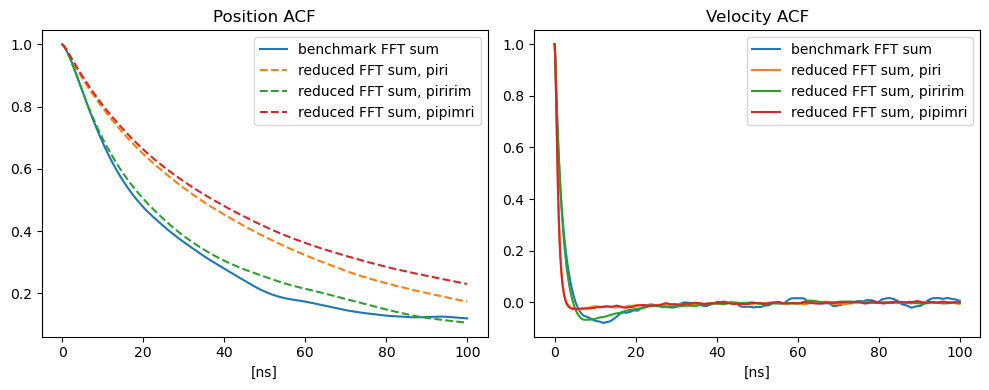

In [40]:
# Plotting comparison for ACFs

# timestep - 0.05 nanoseconds
# 2000 timesteps - 100 ns

time = np.arange(lagtimesteps)*0.05
fig, axes = plt.subplots(1,2, figsize=(10,4))

#axes[0].plot(time, ACF_M[0, 0], label='benchmark M')
axes[0].plot(time, ACF_FFT[0, 0], label='benchmark FFT sum')
#axes[0].plot(time, ACF_M[1, 0], label='reduced M')
for i in range(nModels):
    axes[0].plot(time, ACF_FFT[i+1, 0], '--', label=f'reduced FFT sum, {datasetLabels[i]}')
axes[0].set_title('Position ACF')
axes[0].set_xlabel('[ns]')
axes[0].legend()

#axes[1].plot(time, ACF_M[0, 1], label='benchmark M')
axes[1].plot(time, ACF_FFT[0, 1], label='benchmark FFT sum')
#axes[1].plot(time, ACF_M[1, 1], label='reduced M')
for i in range(nModels):
    axes[1].plot(time, ACF_FFT[i+1, 1], label=f'reduced FFT sum, {datasetLabels[i]}')
axes[1].set_title('Velocity ACF')
axes[1].set_xlabel('[ns]')
axes[1].legend()

plt.tight_layout()
plt.show

In [43]:
# BINNING ON VOXELS

# r_n in [-0.1, 0.1] ; v_n in [-0.5, 0.5]

#print(b_rNxtT.shape, b_vT.shape, b_rAuxT.shape)

# Determine edges of intervals

# r_n in [-0.1, 0.1] ; v_n in [-0.5, 0.5]
print('Velocity Range:')
for i, label in enumerate(dim_labels):
    print(label, ':', float(torch.min(b_vT[:, :, i])), ':', float(torch.max(b_vT[:, :, i])))
    
print('Auxiliary Var Range:')
for i, label in enumerate(dim_labels):
    print(label, ':', float(torch.min(b_rAuxT[:, :, i])), ':', float(torch.max(b_rAuxT[:, :, i])))

# space limits for v and r respectively
limit = [0.6, 0.15]
nBoxes = 20 # number of subfields that the space is divided into PER AXIS (2-d plots will yield nBoxes**2 fields)
boxLength = [2*limit[0]/nBoxes, 2*limit[1]/nBoxes]

# Determine axes to vary r and v: 0 - x, 1 - y, 2 - z axis
v_ax = 0
r_ax = 0


b_voxMeans = torch.zeros((nBoxes, nBoxes, 3))
b_voxStd = torch.zeros((nBoxes, nBoxes, 3))

voxMeans = torch.zeros((nBoxes, nBoxes, 3))
voxStd = torch.zeros((nBoxes, nBoxes, 3))

for i in range(nBoxes):
    for j in range(nBoxes):
        
        v_Int = [-limit[0]+i*boxLength[0], -limit[0]+(i+1)*boxLength[0]]
        r_Int = [-limit[1]+j*boxLength[1], -limit[1]+(j+1)*boxLength[1]]

        mask_v = (b_vT[:, :, v_ax] >= v_Int[0]) & (b_vT[:, :, v_ax] <= v_Int[1])
        mask_r = (b_rAuxT[:, :, r_ax] >= r_Int[0]) & (b_rAuxT[:, :, r_ax] <= r_Int[1])
        mask = mask_v & mask_r

        b_indices = torch.nonzero(mask , as_tuple=True)
        b_voxSamples = b_rNxtT[b_indices]
        
        b_voxMeans[i, j] = torch.mean(b_voxSamples, 0)
        b_voxStd[i, j] = torch.std(b_voxSamples, 0)
        
        mask_v = (vT[mID, :, :, v_ax] >= v_Int[0]) & (vT[mID, :, :, v_ax] <= v_Int[1])
        mask_r = (rAuxT[mID, :, :, r_ax] >= r_Int[0]) & (rAuxT[mID, :, :, r_ax] <= r_Int[1])
        mask = mask_v & mask_r

        indices = torch.nonzero(mask , as_tuple=True)
        voxSamples = rNxtT[mID][indices]
        
        voxMeans[i, j] = torch.mean(voxSamples, 0)
        voxStd[i, j] = torch.std(voxSamples, 0)
                
print(voxMeans[:, :, 0].shape, voxStd.shape)

Velocity Range:
x : -0.6565528512001038 : 0.6312223672866821
y : -0.6617661714553833 : 0.6561468839645386
z : -0.6241325736045837 : 0.577428936958313
Auxiliary Var Range:
x : -0.14277835190296173 : 0.15147076547145844
y : -0.14933818578720093 : 0.1425478458404541
z : -0.155211940407753 : 0.16026999056339264


/tmp/ipykernel_2807627/1017125779.py:48: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /croot/pytorch-select_1730848721463/work/aten/src/ATen/native/ReduceOps.cpp:1807.)
  b_voxStd[i, j] = torch.std(b_voxSamples, 0)
/tmp/ipykernel_2807627/1017125779.py:58: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /croot/pytorch-select_1730848721463/work/aten/src/ATen/native/ReduceOps.cpp:1807.)
  voxStd[i, j] = torch.std(voxSamples, 0)


torch.Size([20, 20]) torch.Size([20, 20, 3])


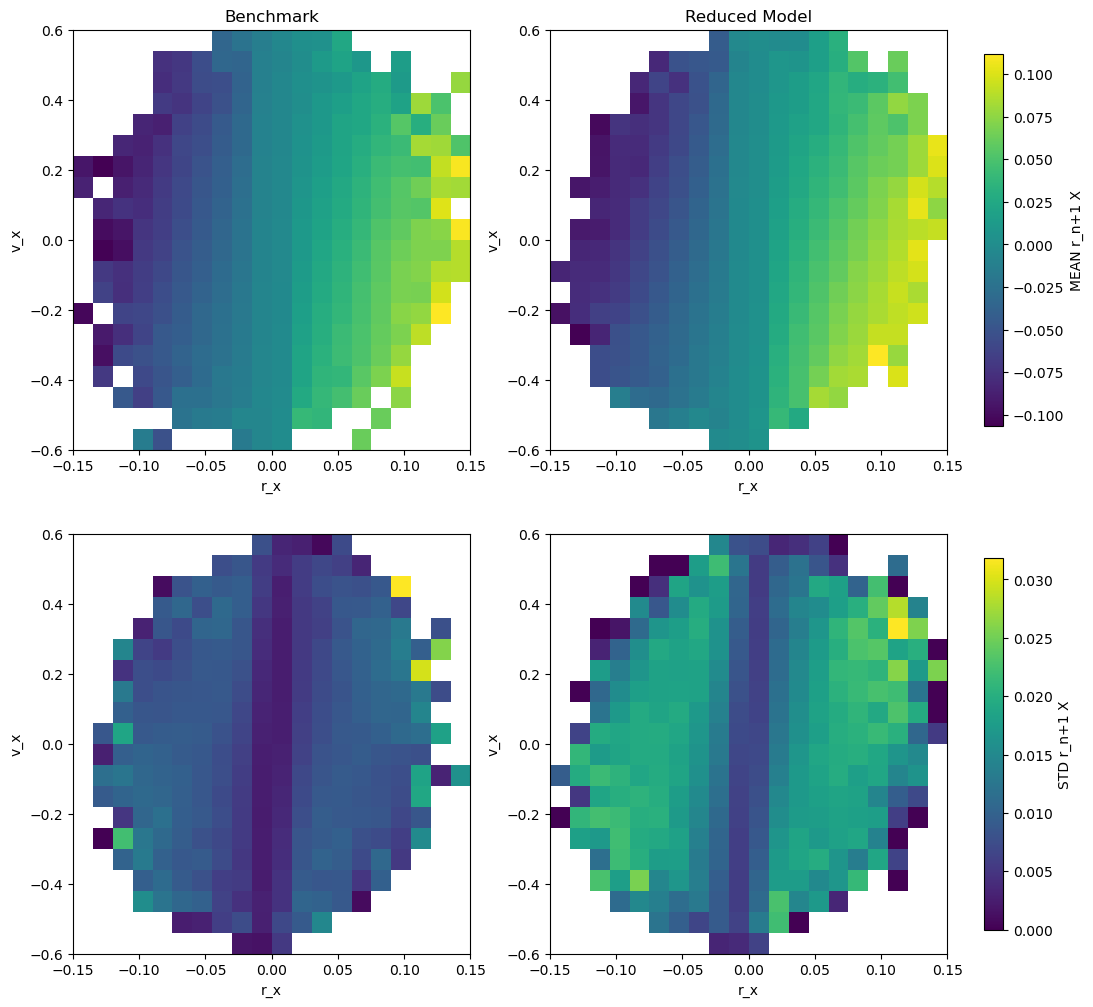

In [44]:
# Dimension to plot: 0 - x, 1 - y, 2 - z
vox_ax = 0

fig, axes = plt.subplots(2, 2, figsize=(12,12))

# Benchmark
im1 = axes[0, 0].imshow(b_voxMeans[:, :, vox_ax], origin='lower', aspect='auto', extent=[-limit[1], limit[1], -limit[0], limit[0]])
im3 = axes[1, 0].imshow(b_voxStd[:, :, vox_ax], origin='lower', aspect='auto', extent=[-limit[1], limit[1], -limit[0], limit[0]])

# Reduced
im1 = axes[0, 1].imshow(voxMeans[:, :, vox_ax], origin='lower', aspect='auto', extent=[-limit[1], limit[1], -limit[0], limit[0]])
im3 = axes[1, 1].imshow(voxStd[:, :, vox_ax], origin='lower', aspect='auto', extent=[-limit[1], limit[1], -limit[0], limit[0]])

axes[0, 0].set_title('Benchmark')
axes[0, 1].set_title('Reduced Model')

for ax in axes.flatten():
    ax.set_ylabel(f'v_{dim_labels[v_ax]}')
    ax.set_xlabel(f'r_{dim_labels[r_ax]}')


fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.02, pad=0.04, label='MEAN r_n+1 X')
fig.colorbar(im3, ax=axes[1], orientation='vertical', fraction=0.02, pad=0.04, label='STD r_n+1 X')
fig.show()

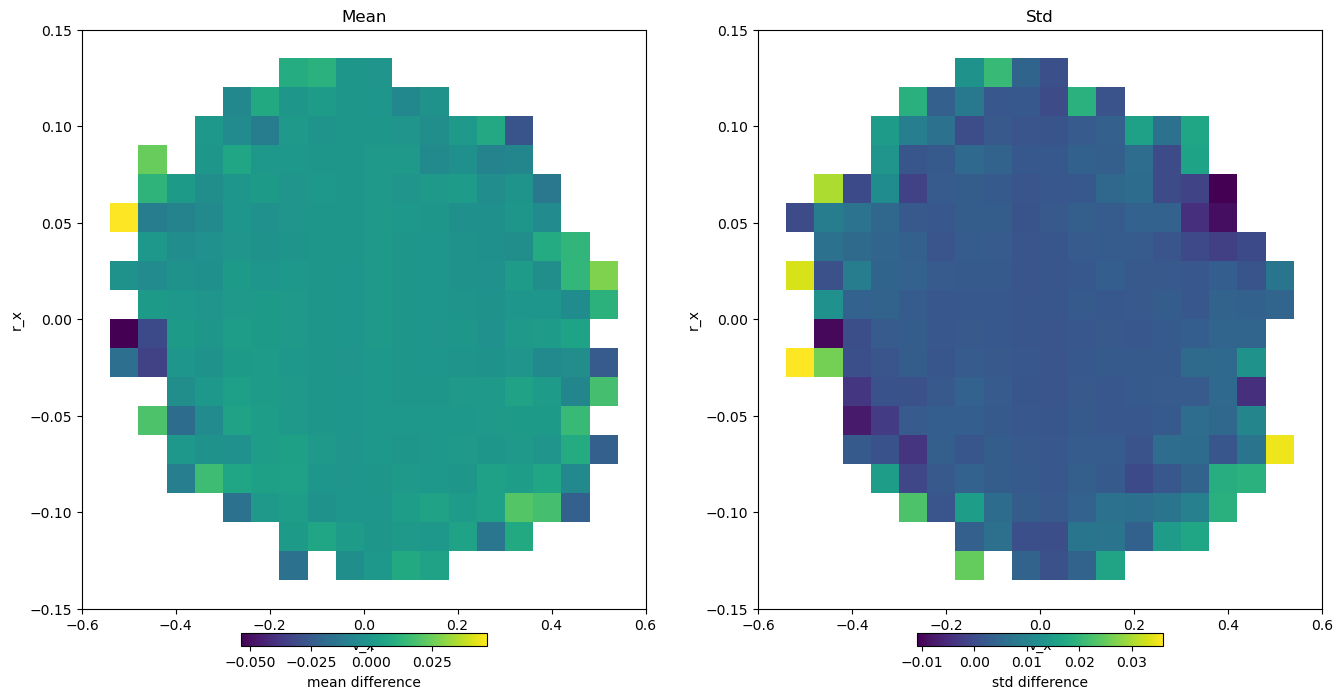

In [23]:
# Plotting the deviation

fig, axes = plt.subplots(1, 2, figsize=(16,8))

# Benchmark
im1 = axes[0].imshow(b_voxMeans[:, :, 0] - voxMeans[:, :, 0], aspect='auto', extent=[-limit[0], limit[0], -limit[1], limit[1]])
im3 = axes[1].imshow(b_voxStd[:, :, 0] - voxStd[:, :, 0], aspect='auto', extent=[-limit[0], limit[0], -limit[1], limit[1]])

axes[0].set_title('Mean')
axes[1].set_title('Std')

for ax in axes.flatten():
    ax.set_xlabel('v_x')
    ax.set_ylabel('r_x')
    
fig.colorbar(im1, ax=axes[0], orientation='horizontal', fraction=0.02, pad=0.04, label='mean difference')
fig.colorbar(im3, ax=axes[1], orientation='horizontal', fraction=0.02, pad=0.04, label='std difference')

fig.show()

In [95]:
b_rNxtT[b_indices].shape, torch.min(b_vT[b_indices][:, 0]), torch.max(b_vT[b_indices][:, 0]), torch.min(b_rAuxT[b_indices][:, 0]), torch.max(b_rAuxT[b_indices][:, 0]) # consistency check
#b_rNxtT[indices].shape

(torch.Size([4, 3]),
 tensor(0.3635),
 tensor(0.4219),
 tensor(0.0915),
 tensor(0.0982))

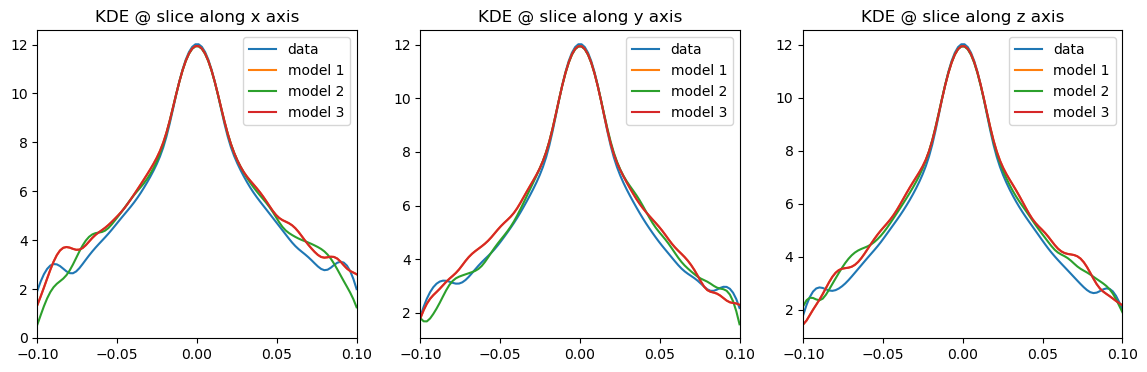

In [68]:
# Kernel Density Estimation - 3-dimensional fit (x,y,z)
axe_lim = 0.1

# Original data
kde1 = KernelDensity(bandwidth=0.005)
kde1.fit(b_rAuxT.flatten(end_dim=1))

# Generated data (reduced model 1)
kde2 = KernelDensity(bandwidth=0.005)
kde2.fit(rAuxT[mID, :, sind:eind].flatten(end_dim=1));

if mID_2 is not None:
    # Second model samples - for comparison
    kde3 = KernelDensity(bandwidth=0.005)
    kde3.fit(rAuxT[mID_2, :, sind:eind].flatten(end_dim=1))
    
if mID_3 is not None:
    # Second model samples - for comparison
    kde4 = KernelDensity(bandwidth=0.005)
    kde4.fit(rAuxT[mID_3, :, sind:eind].flatten(end_dim=1))

# Draw grid
num_gridpts = 100
grid_1d = np.linspace(-axe_lim, axe_lim, num_gridpts)
c_yz = 0.0
E = np.full((num_gridpts,2), c_yz)
grid_slice = np.concatenate((grid_1d[:, np.newaxis], E), axis=1)

fig = plt.figure(figsize=(14,4))

for i, dim in enumerate(dim_labels):
    
    grid_slice = np.insert(E, i, grid_1d, axis=1)

    # Evaluate KDE on grid slice
    pdf_data = kde1.score_samples(grid_slice)
    pdf_gen = kde2.score_samples(grid_slice)
    if mID_2 is not None:
        pdf_gen2 = kde3.score_samples(grid_slice)
    if mID_3 is not None:
        pdf_gen3 = kde4.score_samples(grid_slice)

    # Plotting 3D KDE evaluation at (x, 0, 0)
    ax = fig.add_subplot(1,3,i+1)
    ax.plot(grid_slice[:,i], pdf_data, label='data')
    ax.plot(grid_slice[:,i], pdf_gen, label='model 1')
    if mID_2 is not None:
        ax.plot(grid_slice[:,i], pdf_gen2, label='model 2')
    if mID_3 is not None:
        ax.plot(grid_slice[:,i], pdf_gen3, label='model 3')
    ax.set_title(f'KDE @ slice along {dim} axis')
    ax.set_xlim([-axe_lim, axe_lim])
    ax.legend()
    
fig.show()

In [16]:
z_samples = torch.normal(0, 1.2, (num_samples, self.latentDims))

NameError: name 'num_samples' is not defined

In [15]:
# Estimating mean and cov of latent space distribution
latent_mean = np.mean(np.array(z), axis=0)
latent_cov = np.cov(np.array(z), rowvar=0)
#print(latent_mean, [latent_cov[i, i] for i in range(latentDims)])


# Extracting principal components
pca = PCA(n_components=latentDims)
pca.fit(z)
print('Explained variance distribution:\n', pca.explained_variance_ratio_)

lax = 4
#pts = np.random.choice(inds, 10000)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.scatter(z[inds, 0], z[inds, 1], s=0.5, alpha=0.5)
circle1 = plt.Circle((0, 0), 2, color='r', fill=False)
ax1.add_patch(circle1)
ax1.set_xlim([-lax, lax])
ax1.set_ylim([-lax, lax])
ax1.set_title('Latent space distribution from test data')

ax2.scatter(z_gen[inds, 0], z_gen[inds, 1], s=0.5, alpha=0.5)
circle1 = plt.Circle((0, 0), VAE.cutoff, color='r', fill=False)
ax2.add_patch(circle1)
ax2.set_xlim([-lax, lax])
ax2.set_ylim([-lax, lax])
ax2.set_title('Generated latent points')

fig.show()

NameError: name 'z' is not defined